(31962, 3)
label
0    29720
1     2242
Name: count, dtype: int64
Positive tweet example:
 @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run

Negative tweet example:
@user #cnn calls #michigan middle school 'build the wall' chant '' #tcot  
sentiment
Positive    15880
Neutral     11359
Negative     4723
Name: count, dtype: int64


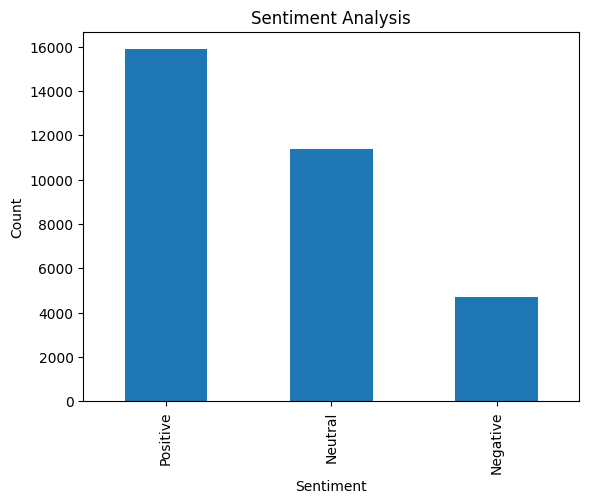

[('&amp;', 346), ('like', 239), ('bear', 216), ('polar', 215), ('sad', 214), ('-', 206), ('people', 199), ('get', 150), ('climb', 144), ('hate', 144)]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.95
Sentiments: Positive


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob
import nltk
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
df = pd.read_csv(url)
df.head()

print(df.shape)
print(df["label"].value_counts())

df["label"].value_counts()
df.isnull().sum()

print("Positive tweet example:")
print(df[df["label"]==0]["tweet"].iloc[0])

print("\nNegative tweet example:")
print(df[df['label']==1]['tweet'].iloc[0])

def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["tweet"].apply(get_sentiment)
print(df["sentiment"].value_counts())

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Analysis")
plt.ylabel("Count")
plt.xlabel("Sentiment")
plt.show()

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))
stop_words.add("@user")

positive_tweets = df[df["sentiment"] == "Negative"]["tweet"]
words = ' '.join(positive_tweets).split()
filtered_words = [w for w in words if w.lower() not in stop_words]
word_freq = Counter(filtered_words).most_common(10)
print(word_freq)

X = df["tweet"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

predictions = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

test_tweet = ["I hate this terrible day!"]
test_tfidf = vectorizer.transform(test_tweet)
predictions = model.predict(test_tfidf)
print(f"Sentiments: {"Positive" if predictions[0]==0 else "Negative"}")




## Word Frequency Analysis
Positive tweets dominated by: love, happy, good
Negative tweets dominated by: sad, hate, polar bear
Unexpected finding: negative tweets contain significant
discussion about polar bears, suggesting environmental
concerns are a common negative topic.
a

## Machine Learning Results
Logistic Regression with TF-IDF achieved 95% accuracy
predicting tweet sentiment — our best ML result yet!
Text classification benefits from strong word-level patterns
that make sentiment highly predictable from vocabulary alone.


## Model Limitations
Despite 95% overall accuracy, the model shows bias toward
positive predictions due to class imbalance 93% positive
training data. A negative test tweet was incorrectly
classified as positive — highlighting that accuracy alone
can be misleading with imbalanced datasets.